In [772]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

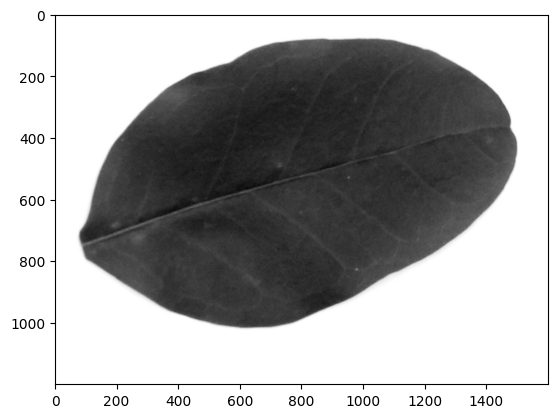

In [773]:
im = cv.cvtColor(cv.imread("./Leaves/3060.jpg"), cv.COLOR_BGR2GRAY)
plt.imshow(im, cmap="gray")

In [774]:
im.shape

(1200, 1600)

### Image segmentation

In [775]:
im_segmentation = cv.threshold(im, 0,255,+cv.THRESH_OTSU)

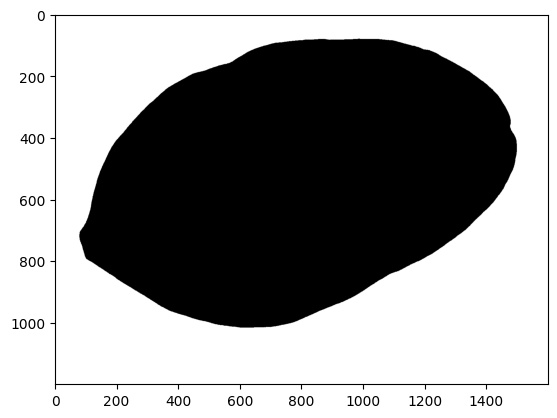

In [776]:
plt.imshow(im_segmentation[1], cmap="gray")


## Extracción de bordes

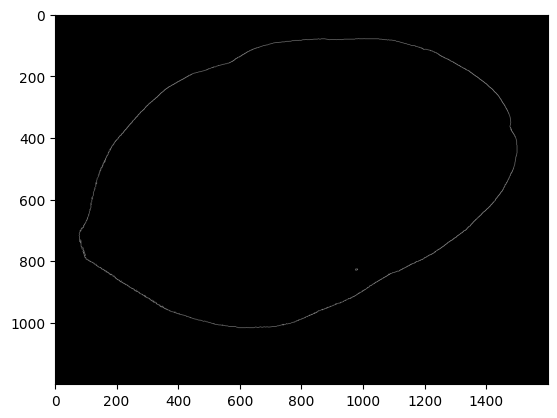

In [777]:
edged = cv.Canny(im, 0, 110)

plt.imshow(edged, cmap="gray")

## Extracción de contornos

In [778]:
contours, hierarchy = cv.findContours(im_segmentation[1], cv.RETR_LIST, cv.CHAIN_APPROX_NONE)

In [779]:
black_im = np.zeros((im.shape[0], im.shape[1]))

## Calcular area


In [780]:
max_area = -1
max_contour = None
image_area = im.shape[0] * im.shape[1]
for contour in contours:
  
    area = cv.contourArea(contour)

    # Drawing a bounding box
    if area <= image_area * 0.9:
        if  area > max_area:
            max_area = area
            max_contour = contour
        

x, y, w, h = cv.boundingRect(max_contour)
cv.rectangle(black_im, (x, y), (x+w, y+h), (255, 255, 255), 2)


# Perimeter

perim = cv.arcLength(max_contour, True) # Verificar

In [781]:
print(f"Tenemos el alto {h} ancho {w} y perimetro de la hoja {perim} relacion de aspecto {w/h}")

Tenemos el alto 939 ancho 1422 y perimetro de la hoja 3914.3842346668243 relacion de aspecto 1.5143769968051117


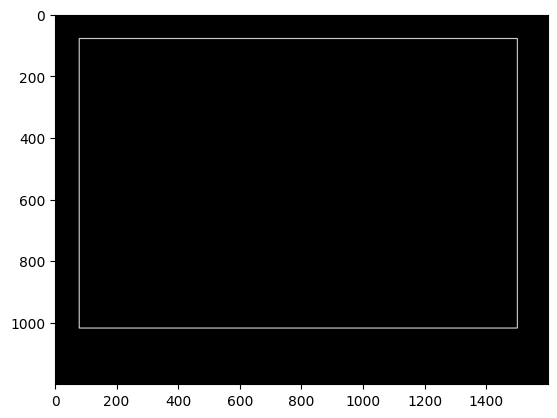

In [782]:
plt.imshow(black_im, cmap="gray")

Usando los puntos del contorno de mayor area realizamos PCA

In [783]:
points = np.array(max_contour).reshape(-1,2).astype(np.float32)
mean, eigvec, eigval = cv.PCACompute2(points, mean=None)

In [784]:
eigvec[0] # Eje mayor
eigvec[1] # Eje menor

array([0.31465918, 0.94920474], dtype=float32)

In [785]:
print("Number of Contours Found = " + str(len(contours)))

Number of Contours Found = 2
